## Imports

In [4]:
# importing sys
import sys
# This is how you import modules that exist outside of working directory 
# adding mosaique to the system path
sys.path.insert(1, '/workspaces/QML-QPF/mosaiQue') 

import mosaique as mq
import scipy
from concurrent.futures import ProcessPoolExecutor, as_completed
import itertools
import numpy as np
import pennylane as qml
import os
from mosaique.models.operation import OperationLayer
from tensorflow import keras
import tensorflow as tf 


In [ ]:
# if the below cell raise this error [ModuleNotFoundError: No module named 'tensorrt']
# uncomment and run the next line, then restart the kernel 
# pip install tensorrt

## Check GPU installation is working

In [ ]:
import tensorrt as trt

print(f' tensorflow version {tf.__version__}')

print(f' tensorrt version {trt.__version__}')

print(tf.config.list_physical_devices('GPU'))

In [ ]:

# Set the environment for asynchronous GPU usage
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'

In [2]:
def operation():
    dev = qml.device("default.qubit.tf", wires=4)
    @qml.qnode(dev, interface='tf')
    def cnot(inputs):
        inputs = inputs * np.pi
        qml.AngleEmbedding(inputs[:,...], wires=range(4), rotation='Y')

        qml.CNOT(wires=[0, 1])
        qml.CNOT(wires=[2, 3])

        # Measurement producing 4 classical output values
        return [qml.expval(qml.PauliZ(j)) for j in range(4)]
    return cnot


In [5]:
def preset():
    # Import the images
    from medmnist import OCTMNIST
    # size of the images 
    size = 28
    # we'll run the code for 64 to see if we'll get different results
    train_data = OCTMNIST(split="train", download=True,size=size)
    test_data = OCTMNIST(split="test", download=True,size=size)
    # name of the folder where will save the filtered images for training
    
    # name of the folder where will save the filtered images for training
    tr_layer = mq.ConvolutionLayer4x4("_OA_results_OCTMNIST_train_with_val")
    # name of the folder where will save the filtered images for testing
    te_layer = mq.ConvolutionLayer4x4("_OA_results_OCTMNIST_test_with_val")
    
    
        
    #load the data set want to train
    (tr_images, tr_labels), (te_images, te_labels) = (train_data.imgs, train_data.labels), (test_data.imgs, test_data.labels)
    

    tr_layer.fit(tr_images)
    te_layer.fit(te_images)
    tr_images = tr_layer.transform(tr_images)
    te_images = te_layer.transform(te_images)
    return ((tr_layer, (tr_images, tr_labels)), (te_layer,(te_images, te_labels)))

with ProcessPoolExecutor() as executor:
    future = executor.submit(preset)

((train_layer, (train_images, train_labels)), (test_layer,(test_images, test_labels))) = future.result() #This blocks until the task completes

In [3]:
test_images.shape

(1000, 196, 4)

In [6]:
np.unique(train_labels)

array([0, 1, 2, 3], dtype=uint8)

In [7]:

permutations = np.asarray(list(itertools.permutations(range(4))))

def pool(x, call, p, l):
    op = OperationLayer(call())
    predict = l.post_transform(op.pre_op.predict(x,batch_size=1000))
    l.save(predict, p)

In [ ]:
# # not using PorcessPoolExecutor

# for p in permutations:
#     pool(train_images[:,:,p],)

In [7]:
for j in range(3):
    with ProcessPoolExecutor(8) as executor:
        runner = {
            executor.submit(pool, x=train_images[:,:,p], call=operation, p=p, l=train_layer): p for p in permutations[8*j:8*(j+1)]
        }
        for future in as_completed(runner):
            runner.pop(future)

98/98 [==============================] - 66s 619ms/step


In [8]:
for j in range(3):
    with ProcessPoolExecutor(8) as executor:
        runner = {
            executor.submit(pool, x=test_images[:,:,p], call=operation, p=p, l=test_layer): p for p in permutations[8*j:8*(j+1)]
        }
        for future in as_completed(runner):
            runner.pop(future)

1/1 [==============================] - 3s 3s/step


In [7]:
from keras.callbacks import CSVLogger, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# change the subfolder name to save your data in different location based on what NN model you used
# it's a convenient way to avoid losing your training data of each model
# Here are some preset examples you can use
# 1 FC layer
# run_subfolder = "_1FC"
# run_subfolder = "_2nodes_2FC"
# # 2 FC layer
# run_subfolder = "_2FC"
# # 3 FC layer
run_subfolder = "_3FC"
# # 4 FC layer
# run_subfolder = "_4FC"
# early stopping epochs -- good practice between 10-20
patience = 15
def run(tr_images, label):
    log_dir = train_layer.name + "/run" + run_subfolder +  "/"
    log_dir += str(patience) +  "/"
    # print(' log_dir ', log_dir)
    log_file =  log_dir + label
    # print(' log_file ', log_file)
    os.makedirs(log_dir, exist_ok=True)
    
    csv_logger = CSVLogger(log_file)
    
    
    # tensorboard_callback = keras.callbacks.TensorBoard(
    #     log_dir=log_file,
    #     histogram_freq=1,
    #     write_graph=True,
    #     write_images=True,
    #     write_steps_per_second=True,
    #     update_freq='batch',
    #     profile_batch=1,
    #     embeddings_freq=1,
    #     embeddings_metadata=None
    # )
    
    number_of_classes = len(np.unique(test_labels))
    # Chose which model you want to use depending on the number of hidden layers
    # Uncomment the your model and run the code--pay attention to your folder/file naming to keep everything organized 
    ####---------------------------------------------------------------------####
    
    # # simple ANN model with 0 hidden layers: 1FC
    # q_model = keras.models.Sequential([
    #     keras.layers.Rescaling(scale=-1. / 127.5, offset=1),
    #     keras.layers.Flatten(),
    #     keras.layers.Dense(number_of_classes, activation="softmax")
    # ])
    
    ####---------------------------------------------------------------------####
    
    # # simple ANN model with 1 hidden layers: 2FC
    # q_model = keras.models.Sequential([
    #     keras.layers.Rescaling(scale=-1. / 127.5, offset=1),
    #     keras.layers.Flatten(),
    #     keras.layers.Dense(512, activation='relu'),
    #     keras.layers.Dense(number_of_classes, activation="softmax")
    # ])
    
    ####---------------------------------------------------------------------####
    
    # simple ANN model with 2 hidden layers: 3FC
    q_model = keras.models.Sequential([
        keras.layers.Rescaling(scale=-1. / 127.5, offset=1),
        keras.layers.Flatten(),
        keras.layers.Dense(512, activation='relu'),
        keras.layers.Dense(256, activation='relu'),
        keras.layers.Dense(number_of_classes, activation='softmax')
    ])
    
    ####---------------------------------------------------------------------####
    
    # # simple ANN model with 3 hidden layers: 4FC
    # q_model = keras.models.Sequential([
    #     keras.layers.Rescaling(scale=-1. / 127.5, offset=1),
    #     keras.layers.Flatten(),
    #     keras.layers.Dense(512, activation='relu'),
    #     keras.layers.Dense(256, activation='relu'),
    #     keras.layers.Dense(128, activation='relu'),
    #     keras.layers.Dense(number_of_classes, activation='softmax')
    # ])
    
    ####---------------------------------------------------------------------####
    
    q_model.compile(
        optimizer='adam',
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    
    # 
    batch_size = 128
    epochs = 60
    
    
    # Stop training when a monitored metric has stopped improving.
    Early_stop = EarlyStopping(monitor="val_accuracy",
                                min_delta=0, # Minimum change in the monitored quantity to qualify as an improvement, i.e. an absolute change of less than min_delta, will count as no improvement.
                                patience=patience, # Number of epochs with no improvement after which training will be stopped.
                                verbose=1, # 1 displays messages when the callback takes an action
                                mode="max", # will stop when the quantity monitored has stopped increasing
                                baseline=None,
                                restore_best_weights=True, # to restore model weights from the epoch with the best value of the monitored quantity
                                start_from_epoch=0, #  Number of epochs to wait before starting to monitor improvement.
                            )

    
    # Callback to save the Keras model or model weights at some frequency.
    checkpoint_filepath = log_file  + 'model.keras'
    model_checkpoint_callback = ModelCheckpoint(filepath=checkpoint_filepath,
                                                monitor='val_accuracy',
                                                mode='max',
                                                verbose=1,
                                                save_best_only=True
                                                )
    # Reduce learning rate when a metric has stopped improving.
    reduce_lr_acc = ReduceLROnPlateau(monitor='val_accuracy',
                                        factor=0.1, # Float. Factor by which the learning rate will be reduced. new_lr = lr * factor.
                                        patience=10, # Integer. Number of epochs with no improvement after which learning rate will be reduced.
                                        verbose=1, # 1: update messages.
                                        mode="max", # 'max' mode it will be reduced when the quantity monitored has stopped increasing
                                        min_delta=0.0001, # Float. Threshold for measuring the new optimum, to only focus on significant changes.
                                        cooldown=0, #  Integer. Number of epochs to wait before resuming normal operation after the learning rate has been reduced.
                                        min_lr=0.0 #  Float. Lower bound on the learning rate.
                                    )


    
    q_history = q_model.fit(
        tr_images,
        train_labels,
        # validation_data=(te_images, test_labels),
        validation_split=0.2,
        batch_size=batch_size,
        epochs=epochs,
        verbose=2,
        # callbacks=[tensorboard_callback]
        callbacks = [Early_stop,csv_logger,model_checkpoint_callback, reduce_lr_acc]
    )

def model(variant, tr_layer):
    tr_images = tr_layer.open(variant)
    # te_images =  te_layer.open(variant)

    label = ''.join(map(str,variant))

    run(tr_images, label)

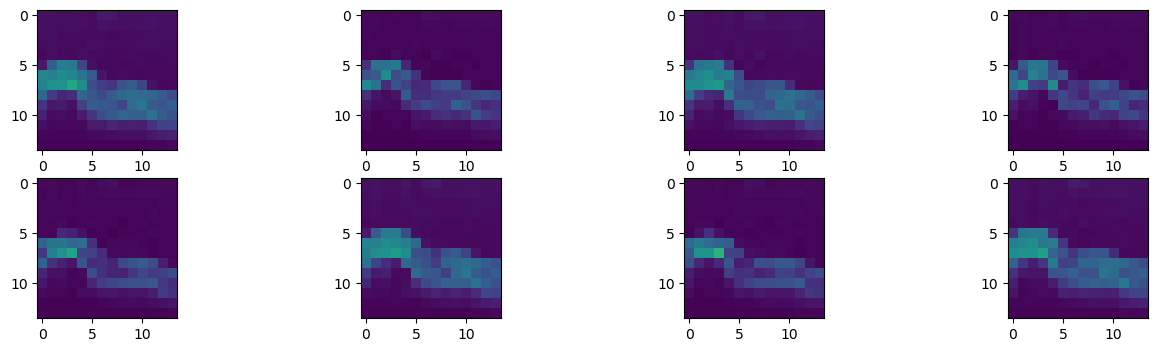

In [5]:
from matplotlib import pyplot as plt

# print(test_layer.open([0,1,3,2]).shape)

# post = test_layer.open([0,1,3,2])

# _min, _max = np.amin(post), np.amax(post)
# fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# # Plot all output channels for quantum cnot
# for c in range(4):
#     axes[c].imshow(post[0,:,:,c],vmin = _min, vmax = _max)
    
post = train_layer.open([1,2,3,0])
post1 = train_layer.open([2,3,0,1])


_min, _max = np.amin(post), np.amax(post)
_min1, _max1 = np.amin(post1), np.amax(post1)
fig, axes = plt.subplots(2, 4, figsize=(16, 4))

# Plot all output channels for quantum cnot
for c in range(4):
    axes[0,c].imshow(post[0,:,:,c],vmin = _min, vmax = _max)
    axes[1,c].imshow(post1[0,:,:,c],vmin = _min1, vmax = _max1)

In [5]:

for j in range(3):
    with ProcessPoolExecutor(8) as executor:
        runner = {
            executor.submit(model,variant = p, tr_layer = train_layer): p for p in permutations[8*j:8*(j+1)]
        }
        for future in as_completed(runner):
            runner.pop(future)

Epoch 1/60
Epoch 1/60
Epoch 1/60
Epoch 1/60
Epoch 1/60
Epoch 1/60
Epoch 1/60
Epoch 1/60

Epoch 1: val_accuracy improved from -inf to 0.60392, saving model to _OA_results_OCTMNIST_train_with_val/run_1FC/15/0213model.keras
610/610 - 3s - loss: 1.0955 - accuracy: 0.5609 - val_loss: 1.0452 - val_accuracy: 0.6039 - lr: 0.0010 - 3s/epoch - 4ms/step
Epoch 2/60

Epoch 1: val_accuracy improved from -inf to 0.61469, saving model to _OA_results_OCTMNIST_train_with_val/run_1FC/15/0231model.keras

Epoch 1: val_accuracy improved from -inf to 0.58073, saving model to _OA_results_OCTMNIST_train_with_val/run_1FC/15/0312model.keras

Epoch 1: val_accuracy improved from -inf to 0.53431, saving model to _OA_results_OCTMNIST_train_with_val/run_1FC/15/0321model.keras

Epoch 1: val_accuracy improved from -inf to 0.58315, saving model to _OA_results_OCTMNIST_train_with_val/run_1FC/15/1032model.keras
610/610 - 3s - loss: 1.0826 - accuracy: 0.5676 - val_loss: 1.0352 - val_accuracy: 0.6147 - lr: 0.0010 - 3s/epoch

In [ ]:
# for ind, variant  in enumerate(permutations):

#     label = ''.join(map(str,variant))
#     print(ind, label)
#     tr_images = train_layer.open(variant)
#     te_images =  test_layer.open(variant)
#     run(tr_images,te_images,label)

In [ ]:
# # run the network without filter
# P = ["NO-FILTER",]
# with ProcessPoolExecutor(8) as executor:
#     runner = {
#         executor.submit(run, label= p, tr_images = train_images, te_images= test_images): p for p in P
#     }
#     for future in as_completed(runner):
#         runner.pop(future)

In [ ]:
with ProcessPoolExecutor(max_workers=None) as executor: # max_workers=None uses the number of CPU cores
    results = executor.map(run, (train_images,test_images,"_NO-FILTER"))

In [8]:
# run the network without filter

run(train_images, "NO-FILTER")

Epoch 1/60

Epoch 1: val_accuracy improved from -inf to 0.60489, saving model to _OA_results_OCTMNIST_train_with_val/run_3FC/15/NO-FILTERmodel.keras
610/610 - 7s - loss: 1.0490 - accuracy: 0.5737 - val_loss: 1.0116 - val_accuracy: 0.6049 - lr: 0.0010 - 7s/epoch - 11ms/step
Epoch 2/60

Epoch 2: val_accuracy improved from 0.60489 to 0.67445, saving model to _OA_results_OCTMNIST_train_with_val/run_3FC/15/NO-FILTERmodel.keras
610/610 - 6s - loss: 0.9145 - accuracy: 0.6491 - val_loss: 0.8688 - val_accuracy: 0.6744 - lr: 0.0010 - 6s/epoch - 10ms/step
Epoch 3/60

Epoch 3: val_accuracy improved from 0.67445 to 0.68983, saving model to _OA_results_OCTMNIST_train_with_val/run_3FC/15/NO-FILTERmodel.keras
610/610 - 6s - loss: 0.8492 - accuracy: 0.6791 - val_loss: 0.8304 - val_accuracy: 0.6898 - lr: 0.0010 - 6s/epoch - 11ms/step
Epoch 4/60

Epoch 4: val_accuracy improved from 0.68983 to 0.70963, saving model to _OA_results_OCTMNIST_train_with_val/run_3FC/15/NO-FILTERmodel.keras
610/610 - 7s - loss:

# Read Validation accuracy 
Now we will read from the csv and group the experiment validation for the last 30 epoch into the symmetries

In [8]:
# # change the subfolder name to save your data in different location based on what NN model you used
# # it's a convenient way to avoid losing your training data of each model
# # Here are some preset examples you can use
# # 1 FC layer
# run_subfolder = "_1FC"
# # run_subfolder = "_2nodes_2FC"
# # # 2 FC layer
# run_subfolder = "_2FC"
# # # 3 FC layer
# run_subfolder = "_3FC"
# # # 4 FC layer
run_subfolder = "_4FC"
# early stopping epochs -- good practice between 10-20
patience = 15
log_dir = train_layer.name + "/run" + run_subfolder +  "/"
log_dir += str(patience) +  "/"


In [9]:
# group the index of the permutation by the symmetry of the filter

diagonal_index = [4, 5, 8, 9, 14, 15, 18, 19]
vertical_index = [0, 1, 6, 7, 16, 17, 22, 23]
horizontal_index = [2, 3, 10, 11, 12, 13, 20, 21]

### Finding the best model/worst for each symmetry

In [10]:
import pandas as pd

diagonal_val_accuracy = []
vertical_val_accuracy = []
horizontal_val_accuracy = []

diagonal_max_accuracy, vertical_max_accuracy, horizontal_max_accuracy = 0, 0, 0
diagonal_min_accuracy, vertical_min_accuracy, horizontal_min_accuracy = 0, 0, 0
diagonal_best_model, vertical_best_model, horizontal_best_model = "", "", ""
diagonal_worst_model, vertical_worst_model, horizontal_worst_model = "", "", ""
diagonal_max_accuracy_filepath, vertical_max_accuracy_filepath, horizontal_max_accuracy_filepath = "", "", ""
diagonal_best_model_filepath, vertical_best_model_filepath, horizontal_best_model_filepath = "", "", ""


for ind, variant  in enumerate(permutations):
    label = ''.join(map(str,variant))
    # file = train_layer.name + "/run" + run_subfolder +  "/" + label
    file = log_dir + label
    # print(file)
    #read the csv file
    df = pd.read_csv(file)
    # print(df)
    # print("Max ", df['val_accuracy'].max())
    # the number of last validation accuracy
    tail_accuracy = 30
    # our models file path extension, we'll use it to capture the filepath to our models
    model_filepath_extension = "model.keras"
    # Checking only diagonal models
    if ind in diagonal_index:
        if not diagonal_max_accuracy:
            # Assuming the max accuracy of the first model is both the max and min of the entire model with
            # respect to a given symmetry
            diagonal_max_accuracy = df['val_accuracy'].max()
            diagonal_best_model = label
            # saving the file path of the model and accuracies
            diagonal_max_accuracy_filepath = file
            diagonal_best_model_filepath = file + model_filepath_extension
            # capturing the lowest out of the highest accuracies of our models
            diagonal_min_accuracy = df['val_accuracy'].max()
            diagonal_worst_model = label
        # This block will only start from the second model 
        elif diagonal_max_accuracy < df['val_accuracy'].max():
            diagonal_max_accuracy = df['val_accuracy'].max()
            diagonal_best_model = label
            # saving the file path of the model and accuracies
            diagonal_max_accuracy_filepath = file
            diagonal_best_model_filepath = file + model_filepath_extension
        # This block will only start from the second model    
        elif diagonal_min_accuracy > df['val_accuracy'].max():
            diagonal_min_accuracy = df['val_accuracy'].max()
            diagonal_worst_model = label
    
    # Checking only vertical models    
    elif ind in vertical_index:
        if not vertical_max_accuracy:
            # Assuming the max accuracy of the first model is both the max and min of the entire model with
            # respect to a given symmetry
            vertical_max_accuracy = df['val_accuracy'].max()
            vertical_best_model = label
            # saving the file path of the model and accuracies
            vertical_max_accuracy_filepath = file
            vertical_best_model_filepath = file + model_filepath_extension
            # capturing the lowest out of the highest accuracies of our models
            vertical_min_accuracy = df['val_accuracy'].max()
            vertical_worst_model = label
        # This block will only start from the second model    
        elif vertical_max_accuracy < df['val_accuracy'].max():
            vertical_max_accuracy =  df['val_accuracy'].max()
            vertical_best_model = label
            # saving the file path of the model and accuracies
            vertical_max_accuracy_filepath = file
            vertical_best_model_filepath = file + model_filepath_extension
        # This block will only start from the second model    
        elif vertical_min_accuracy > df['val_accuracy'].max():
            vertical_min_accuracy = df['val_accuracy'].max()
            vertical_worst_model = label
            
    # Checking only horizontal models
    elif ind in horizontal_index:
        if not horizontal_max_accuracy:
            # Assuming the max accuracy of the first model is both the max and min of the entire model with
            # respect to a given symmetry
            horizontal_max_accuracy = df['val_accuracy'].max()
            horizontal_best_model = label
            # saving the file path of the model and accuracies
            horizontal_max_accuracy_filepath = file
            horizontal_best_model_filepath = file + model_filepath_extension
            # capturing the lowest out of the highest accuracies of our models
            horizontal_min_accuracy = df['val_accuracy'].max()
            horizontal_worst_model = label
        # This block will only start from the second model    
        elif horizontal_max_accuracy < df['val_accuracy'].max():
            horizontal_max_accuracy = df['val_accuracy'].max()
            horizontal_best_model = label
            # saving the file path of the model and accuracies
            horizontal_max_accuracy_filepath = file
            horizontal_best_model_filepath = file + model_filepath_extension
        # This block will only start from the second model    
        elif horizontal_min_accuracy > df['val_accuracy'].max():
            horizontal_min_accuracy = df['val_accuracy'].max()
            horizontal_worst_model = label
            
# printing the models
print(f" The best diagonal model is: {diagonal_best_model} with accuracy {diagonal_max_accuracy}" )
print(f" The best diagonal model filepath is: {diagonal_best_model_filepath}")
print(f" The best diagonal model accuracy filepath is: {diagonal_max_accuracy_filepath}")
print(f" The worst diagonal model is: {diagonal_worst_model} with accuracy {diagonal_min_accuracy}" )

print("#"*70)
print(f" The best vertical model is: {vertical_best_model} with accuracy {vertical_max_accuracy}" )
print(f" The best vertical model filepath is: {diagonal_best_model_filepath}")
print(f" The best vertical model accuracy filepath is: {vertical_max_accuracy_filepath}")
print(f" The worst vertical model is: {vertical_worst_model} with accuracy {vertical_min_accuracy}" )
print("#"*70)
print(f" The best horizontal model is: {horizontal_best_model} with accuracy {horizontal_max_accuracy}" )
print(f" The best horizontal model filepath is: {horizontal_best_model_filepath}")
print(f" The best horizontal model accuracy filepath is: {horizontal_max_accuracy_filepath}")
print(f" The worst horizontal model is: {horizontal_worst_model} with accuracy {horizontal_min_accuracy}" )

 The best diagonal model is: 2130 with accuracy 0.8394542336463928
 The best diagonal model filepath is: _OA_results_OCTMNIST_train_with_val/run_4FC/15/2130model.keras
 The best diagonal model accuracy filepath is: _OA_results_OCTMNIST_train_with_val/run_4FC/15/2130
 The worst diagonal model is: 1230 with accuracy 0.8183730244636536
######################################################################
 The best vertical model is: 2301 with accuracy 0.8376590013504028
 The best vertical model filepath is: _OA_results_OCTMNIST_train_with_val/run_4FC/15/2130model.keras
 The best vertical model accuracy filepath is: _OA_results_OCTMNIST_train_with_val/run_4FC/15/2301
 The worst vertical model is: 1032 with accuracy 0.816680371761322
######################################################################
 The best horizontal model is: 2013 with accuracy 0.8478662371635437
 The best horizontal model filepath is: _OA_results_OCTMNIST_train_with_val/run_4FC/15/2013model.keras
 The best horizon

In [11]:
import pandas as pd

diagonal_val_accuracy = []
vertical_val_accuracy = []
horizontal_val_accuracy = []

for ind, variant  in enumerate(permutations):
    label = ''.join(map(str,variant))
    # file = train_layer.name + "/run" + run_subfolder +  "/" + label
    file = log_dir + label

    #read the csv file
    df = pd.read_csv(file)
    
    # the number of last validation accuracy
    tail_accuracy = 15
    diagonal_max_accuracy, vertical_max_accuracy, horizontal_max_accuracy = 0, 0, 0
    if ind in diagonal_index:
        diagonal_val_accuracy.append(df['val_accuracy'].tail(tail_accuracy).tolist())
        
    elif ind in vertical_index:
        vertical_val_accuracy.append(df['val_accuracy'].tail(tail_accuracy).tolist())
    
    elif ind in horizontal_index:
        horizontal_val_accuracy.append(df['val_accuracy'].tail(tail_accuracy).tolist())


In [12]:
# need to flatten the list to have all the data in a single list
diagonal_val_accuracy_flattened = [item for sublist in diagonal_val_accuracy for item in sublist]
vertical_val_accuracy_flattened = [item for sublist in vertical_val_accuracy for item in sublist]
horizontal_val_accuracy_flattened = [item for sublist in horizontal_val_accuracy for item in sublist]


In [13]:
# file = train_layer.name + "/run" + run_subfolder +  "/" + "NO-FILTER"
file = log_dir + "NO-FILTER"


df = pd.read_csv(file)
no_fitler_val_accuracy = df['val_accuracy'].tail(tail_accuracy).tolist()

### No Filter model

In [14]:
nofilter_model_file_path = file + model_filepath_extension

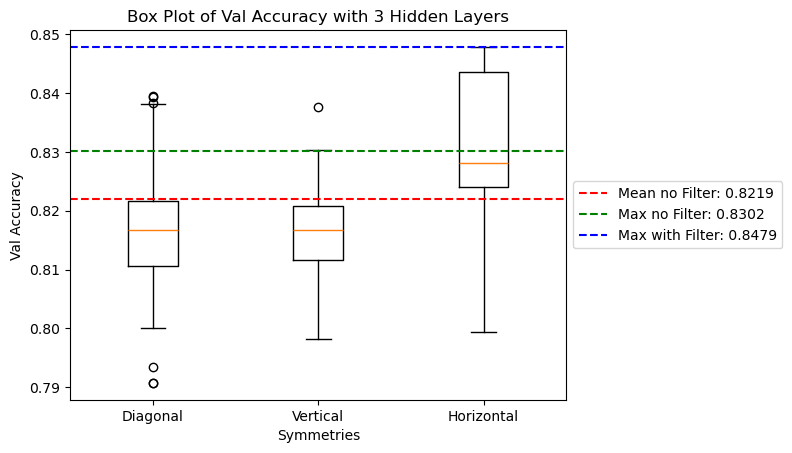

In [15]:
import matplotlib.pyplot as plt

# Combine the data into a list of lists
data = [diagonal_val_accuracy_flattened, vertical_val_accuracy_flattened, horizontal_val_accuracy_flattened]

# Define the labels for the box plot
labels_plot = ['Diagonal', 'Vertical', 'Horizontal']

# Create the box plot
plt.boxplot(data, labels=labels_plot)

# Calculate the mean value of the no_filter list
mean_no_filter = np.mean(no_fitler_val_accuracy)
max_no_filter = np.max(no_fitler_val_accuracy)

# Add a horizontal line at the mean value of no_filter
plt.axhline(y= mean_no_filter, color='r', linestyle='--', label=f'Mean no Filter: {mean_no_filter:.4f}')
plt.axhline(y= max_no_filter, color='g', linestyle='--', label=f'Max no Filter: {max_no_filter:.4f}')

# plt.ylim(0.936,.97)
max_val_accuracy = np.max([diagonal_val_accuracy_flattened, vertical_val_accuracy_flattened, horizontal_val_accuracy_flattened])
plt.axhline(y= max_val_accuracy, color='b', linestyle='--', label=f'Max with Filter: {max_val_accuracy:.4f}')

# Add title and labels
number_of_hidden_layers = str(int(run_subfolder[1])-1)
plt.title(f'Box Plot of Val Accuracy with {number_of_hidden_layers} Hidden Layers')
plt.xlabel('Symmetries')
plt.ylabel('Val Accuracy')
# plt.legend(ncol=2, shadow=True)
# plt.legend(shadow=True)
# plt.legend()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
# Save the figure with high quality
data_name = "OCTMNIST"
figure_name = f"{log_dir}/{data_name}_{run_subfolder}_Val_Accuracy"
# plt.savefig(figure_name, dpi=300, bbox_inches='tight')
# Show the plot
plt.show()


## Now let's evaluate our models

In [16]:
# Loading the models
diagonal_model = keras.saving.load_model(diagonal_best_model_filepath)
vertical_model = keras.saving.load_model(vertical_best_model_filepath)
horizontal_model = keras.saving.load_model(horizontal_best_model_filepath)
nofilter_model = keras.saving.load_model(nofilter_model_file_path)


In [17]:
# Evaluate the model on the test data using 
print("Evaluate on test data")
# Diagonal
diagonal_label = diagonal_max_accuracy_filepath[-4:]
diagonal_te_images =  test_layer.open(diagonal_label)
diagonal_results = diagonal_model.evaluate(diagonal_te_images, test_labels)
print("Diagonal test loss, test acc:", diagonal_results)
print("#"*70)
# Vertical
vertical_label = vertical_max_accuracy_filepath[-4:]
vertical_te_images =  test_layer.open(vertical_label)
vertical_results = vertical_model.evaluate(vertical_te_images, test_labels)
print("Vertical test loss, test acc:", vertical_results)
print("#"*70)
# Horizontal
horizontal_label = horizontal_max_accuracy_filepath[-4:]
horizontal_te_images =  test_layer.open(horizontal_label)
horizontal_results = horizontal_model.evaluate(horizontal_te_images, test_labels)
print("Horizontal test loss, test acc:", horizontal_results)
print("#"*70)
# No Filter
nofilter_te_images =  test_images
nofilter_te_results = nofilter_model.evaluate(nofilter_te_images, test_labels)
print("No Filter test loss, test acc:", nofilter_te_results)
print("#"*70)

Evaluate on test data
32/32 [==============================] - 1s 5ms/step - loss: 1.7634 - accuracy: 0.5960
Diagonal test loss, test acc: [1.7633545398712158, 0.5960000157356262]
######################################################################
32/32 [==============================] - 0s 2ms/step - loss: 1.8096 - accuracy: 0.6040
Vertical test loss, test acc: [1.8096373081207275, 0.6039999723434448]
######################################################################
14/32 [============>.................] - ETA: 0s - loss: 1.7296 - accuracy: 0.5938

32/32 [==============================] - 0s 4ms/step - loss: 1.5981 - accuracy: 0.6150
Horizontal test loss, test acc: [1.5981167554855347, 0.6150000095367432]
######################################################################
32/32 [==============================] - 0s 5ms/step - loss: 1.5925 - accuracy: 0.5840
No Filter test loss, test acc: [1.592537522315979, 0.5839999914169312]
######################################################################


In [18]:
# data to build classification reports
Models_dict = {"diagonal" : {"label":diagonal_label, "model": diagonal_model, "test_images": diagonal_te_images,  "pred": ""},
               "vertical" : {"label":vertical_label, "model": vertical_model, "test_images": vertical_te_images, "pred": ""}, 
                "horizontal" : {"label":horizontal_label, "model": horizontal_model, "test_images": horizontal_te_images, "pred": ""},
            }

 ## Confusion Matrix

32/32 [==============================] - 0s 4ms/step
Confusion matrix saved to _OA_results_OCTMNIST_test_with_val/_4FC/15/confusion_matrices/diagonal_2130_confusion_matrix.csv
################################################################################
Confusion Matrix for Diagonal Model
32/32 [==============================] - 0s 5ms/step
Confusion matrix saved to _OA_results_OCTMNIST_test_with_val/_4FC/15/confusion_matrices/vertical_2301_confusion_matrix.csv
################################################################################
Confusion Matrix for Vertical Model


32/32 [==============================] - 0s 3ms/step
Confusion matrix saved to _OA_results_OCTMNIST_test_with_val/_4FC/15/confusion_matrices/horizontal_2013_confusion_matrix.csv
################################################################################
Confusion Matrix for Horizontal Model


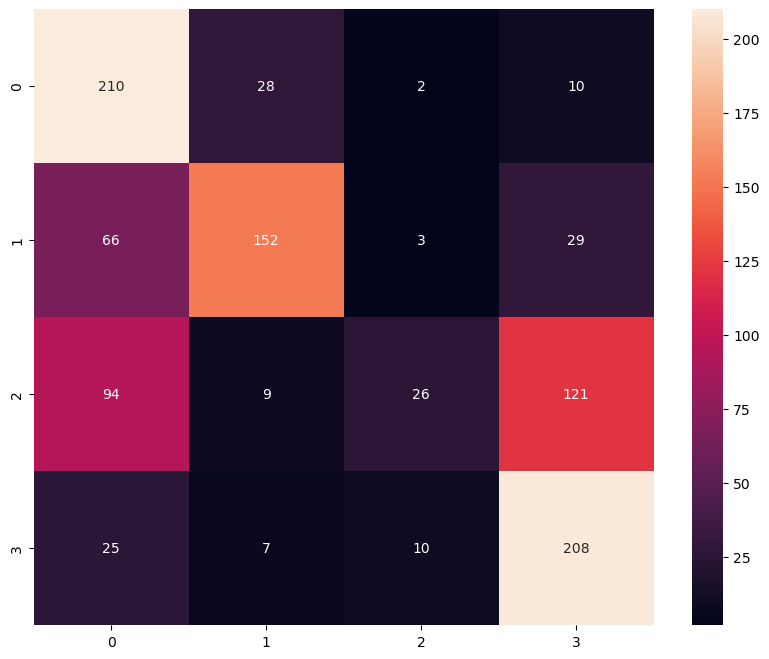

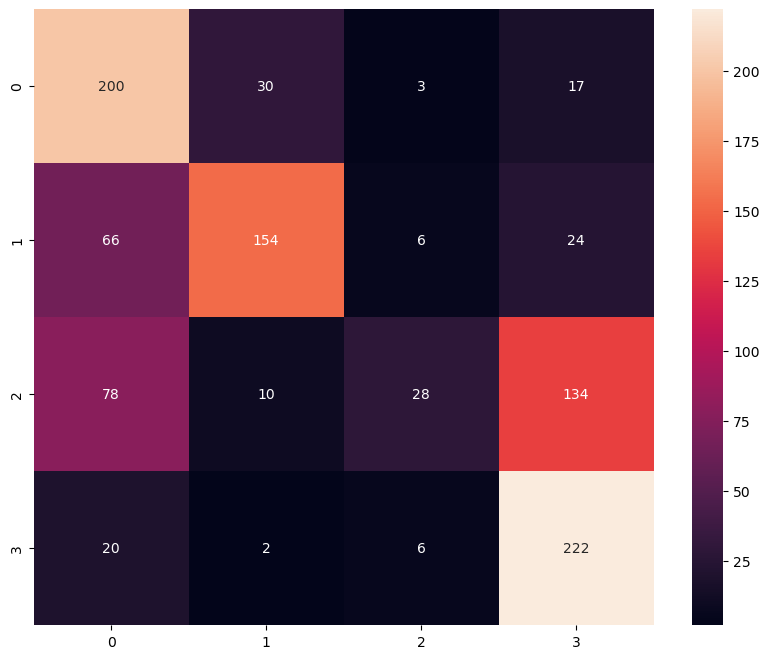

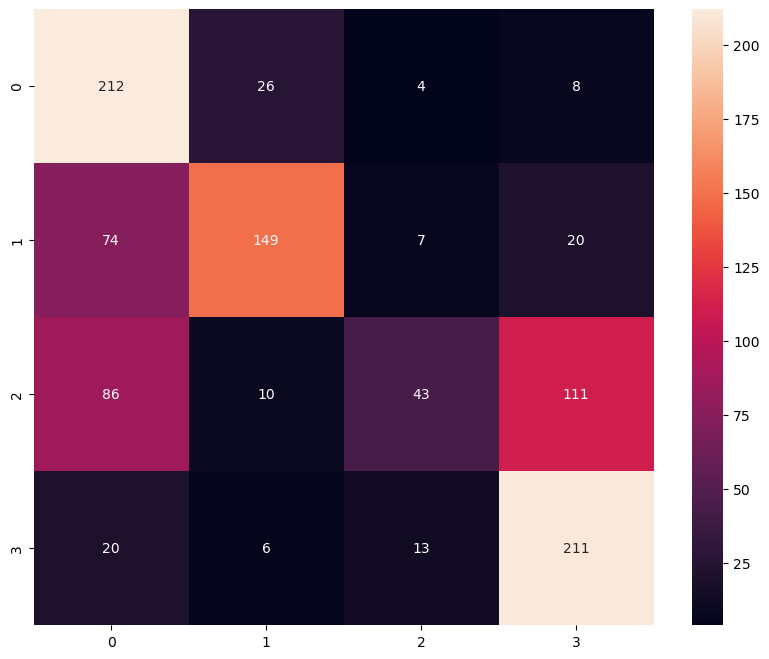

In [19]:
import seaborn as sns

# Function that creates a folder
def create_folder(folder_path):
   log_dir =  os.path.join(os.getcwd(), folder_path)
   os.makedirs(log_dir, exist_ok=True) 
   return log_dir

# creating a folder inside test_data folder to save the confusion matrices and classification reports 
# with name = number of Fully Connected FC layer used.
patience = 15
test_folder_path = test_layer.name  + "/" + run_subfolder +  "/"
# create_folder(test_folder_path)
test_folder_path += str(patience) +  "/"
# test_folder_path = test_layer.name + "/" + run_subfolder
create_folder(test_folder_path)
confusion_matrices_path = test_folder_path + "confusion_matrices"
create_folder(confusion_matrices_path)
# we
class_names = np.unique(test_labels)



def create_save_confusion_matrix(symmetry, Y_pred, label, test_labels=test_labels):
   """ Function that creates & saves as csv and png confusion matrix """
   try:
      # # Convert predictions classes to one hot vectors 
      # Y_pred_classes = np.argmax(Y_pred, axis=1) 
      # compute the confusion matrix
      confusion_mtx = tf.math.confusion_matrix(labels=test_labels,
                                                predictions=Y_pred
                                             )
      confusion_mtx_df = pd.DataFrame(confusion_mtx, index=class_names, columns=class_names)
      # file name to save the confusion matrix
      cm_file_name =  f"{confusion_matrices_path}/{symmetry}_{label}_confusion_matrix.csv"
      print
      # Save to a CSV file
      confusion_mtx_df.to_csv(cm_file_name)
      print(f"Confusion matrix saved to {cm_file_name}")
      print("#"*80)
      print(f"Confusion Matrix for {symmetry.capitalize()} Model")
      plt.figure(figsize=(10, 8))
      sns.heatmap(confusion_mtx, annot=True, fmt='g')
      # Save the figure with high quality
      # cm_file_name[:-4] taking off .csv extension to avoid errors
      plt.savefig(cm_file_name[:-4], dpi=300, bbox_inches='tight')
   
   except Exception as e:
      print(f"An error occurred while creating and saving the confusion_matrix: {e}")


# 
for symmetry, value in Models_dict.items():
   # Predict the values from the testing dataset
   value["pred"] = np.argmax(value["model"].predict(value["test_images"]), axis=1) 
   create_save_confusion_matrix(symmetry, Y_pred=value["pred"], label=value["label"], test_labels=test_labels)


## classification report

Classification report saved to _OA_results_OCTMNIST_test_with_val/_4FC/15/classification_reports/diagonal_2130__classification_report.csv


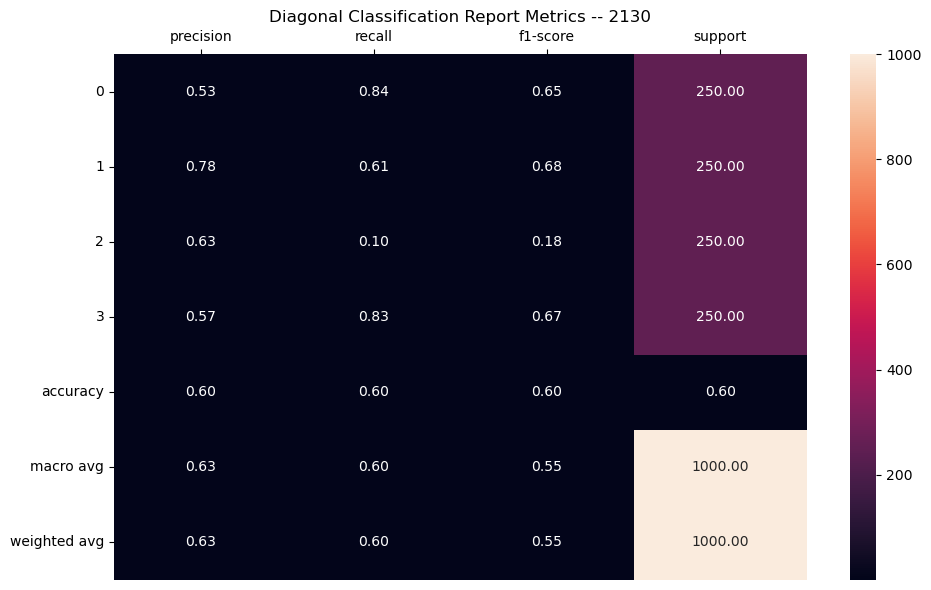

Successfully classification report saved to _OA_results_OCTMNIST_test_with_val/_4FC/15/classification_reports/diagonal_2130__classification_report.png
######################################################################


 Classification Report for diagonal


{'0': {'precision': 0.5316455696202531, 'recall': 0.84, 'f1-score': 0.6511627906976745, 'support': 250.0}, '1': {'precision': 0.7755102040816326, 'recall': 0.608, 'f1-score': 0.6816143497757847, 'support': 250.0}, '2': {'precision': 0.6341463414634146, 'recall': 0.104, 'f1-score': 0.17869415807560138, 'support': 250.0}, '3': {'precision': 0.5652173913043478, 'recall': 0.832, 'f1-score': 0.6731391585760518, 'support': 250.0}, 'accuracy': 0.596, 'macro avg': {'precision': 0.626629876617412, 'recall': 0.596, 'f1-score': 0.546152614281278, 'support': 1000.0}, 'weighted avg': {'precision': 0.626629876617412, 'recall': 0.596, 'f1-score': 0.546152614281278, 'support': 1000.0}}
###########################################################

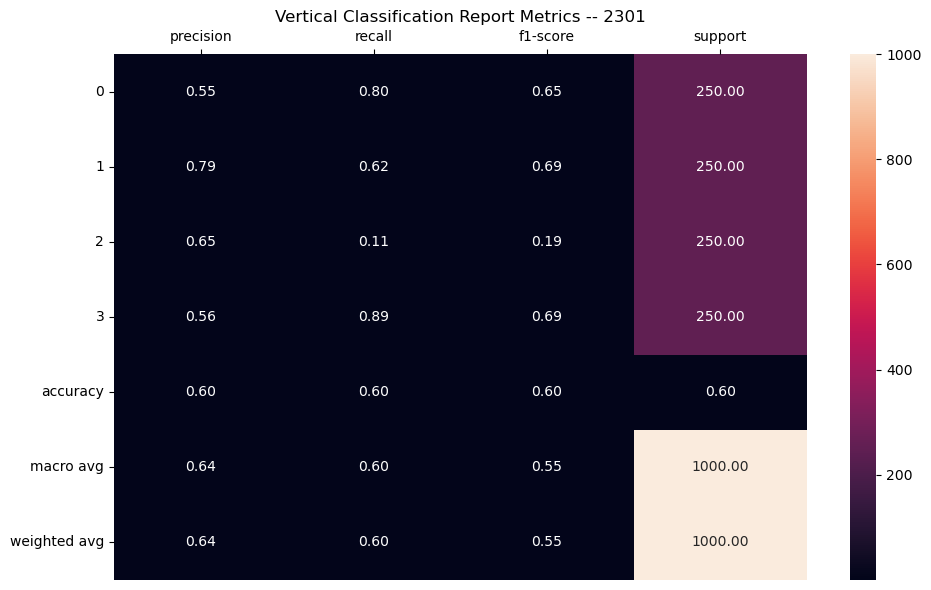

Successfully classification report saved to _OA_results_OCTMNIST_test_with_val/_4FC/15/classification_reports/vertical_2301__classification_report.png
######################################################################


 Classification Report for vertical


{'0': {'precision': 0.5494505494505495, 'recall': 0.8, 'f1-score': 0.6514657980456026, 'support': 250.0}, '1': {'precision': 0.7857142857142857, 'recall': 0.616, 'f1-score': 0.6905829596412556, 'support': 250.0}, '2': {'precision': 0.6511627906976745, 'recall': 0.112, 'f1-score': 0.19112627986348124, 'support': 250.0}, '3': {'precision': 0.5591939546599496, 'recall': 0.888, 'f1-score': 0.6862442040185471, 'support': 250.0}, 'accuracy': 0.604, 'macro avg': {'precision': 0.6363803951306148, 'recall': 0.604, 'f1-score': 0.5548548103922216, 'support': 1000.0}, 'weighted avg': {'precision': 0.6363803951306148, 'recall': 0.604, 'f1-score': 0.5548548103922217, 'support': 1000.0}}
########################################################

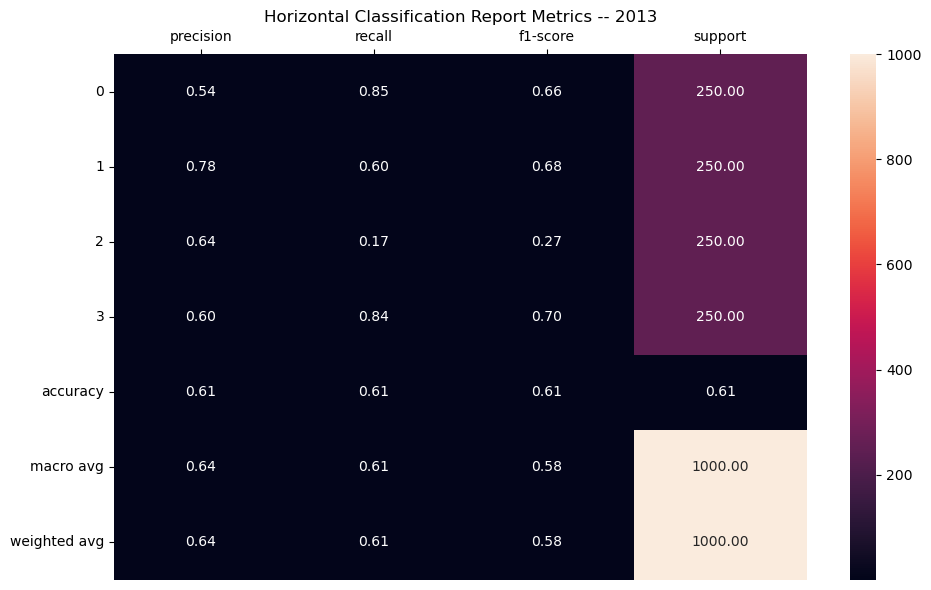

Successfully classification report saved to _OA_results_OCTMNIST_test_with_val/_4FC/15/classification_reports/horizontal_2013__classification_report.png
######################################################################


 Classification Report for horizontal


{'0': {'precision': 0.5408163265306123, 'recall': 0.848, 'f1-score': 0.660436137071651, 'support': 250.0}, '1': {'precision': 0.7801047120418848, 'recall': 0.596, 'f1-score': 0.6757369614512472, 'support': 250.0}, '2': {'precision': 0.6417910447761194, 'recall': 0.172, 'f1-score': 0.27129337539432175, 'support': 250.0}, '3': {'precision': 0.6028571428571429, 'recall': 0.844, 'f1-score': 0.7033333333333334, 'support': 250.0}, 'accuracy': 0.615, 'macro avg': {'precision': 0.6413923065514398, 'recall': 0.615, 'f1-score': 0.5776999518126384, 'support': 1000.0}, 'weighted avg': {'precision': 0.6413923065514398, 'recall': 0.615, 'f1-score': 0.5776999518126383, 'support': 1000.0}}
###################################################

In [20]:
from sklearn.metrics import classification_report

# # creating a folder inside test_data folder to save the classification reports with name = number of Fully Connected FC layer used.
# test_folder_path = test_layer.name + "/" + run_subfolder
# create_folder(test_folder_path)
# creating a folder inside test_data folder to save the classification reports
folder_path = test_folder_path  + "classification_reports"
create_folder(folder_path)


def save_classification_report_image(df_report, symmetry, label, folder_path, class_names=class_names):
    """ Function to save each classification report as an image with symmetry name and configuration e.g. 0123"""
    # extension for the files
    classification_report_image_extension = "_classification_report.png"
    try:
        plt.figure(figsize=(10, len(class_names) + 2))
        sns.heatmap(df_report,
                    annot=True,
                    fmt=".2f",
                    cbar=True)
        
        plt.title(f"{symmetry.capitalize()} Classification Report Metrics -- {label}")
        # Move x-axis labels to the top
        plt.tick_params(axis='x', which='major', top=True, bottom=False, labeltop=True, labelbottom=False)
        plt.xticks(rotation=0, ha='center') # Adjust rotation as needed

        # Save classification report as image
        file_name = f"{folder_path}/{symmetry}_{label}_{classification_report_image_extension}"
        plt.tight_layout()
        plt.savefig(file_name, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"Successfully classification report saved to {file_name}")
    except Exception as e:
        print(f"An error occurred while creating and saving the classification report: {e}")




def create_save_classification_report(Y_pred, symmetry, label, test_labels=test_labels, folder_path=folder_path):
   # extension for classification reports inside the above folder
   classification_report_file_extension = "_classification_report.csv"

   try:
      # building report
      report = classification_report(y_true=test_labels,
                                    y_pred=Y_pred,
                                    output_dict=True
                                    )
      df_report = pd.DataFrame(report).transpose()

      # Save the DataFrame to a CSV file
      file_name = f"{folder_path}/{symmetry}_{label}_{classification_report_file_extension}"
      df_report.to_csv(file_name)
      print(f"Classification report saved to {file_name}")
      # save classification report as image
      save_classification_report_image(df_report=df_report, symmetry=symmetry, label=label, folder_path=folder_path)
      # 
      print("#"*70)
      print("\n")

      print(f" Classification Report for {symmetry}")
      print("\n")
      print(report)
      print("#"*70)
      print("\n")
   except Exception as e:
        print(f"An error occurred while creating and saving the classification report: {e}")
         
         
         
for symmetry, value in Models_dict.items():
    create_save_classification_report(symmetry=symmetry, label=value["label"], Y_pred=value["pred"])
    
print("#"*70)
print("End!") 